# Data Preparation

This notebook documents our full data preparation process for the **Chicago Taxi Trips 2024** dataset (downloaded 10.05.2026). Rather than presenting a clean pipeline upfront, we work through the data step by step: examining the raw data first, surfacing issues, and justifying each cleaning decision as we find it.

All cleaning steps documented here are encapsulated in `scripts/helpers/preprocessing.py` and are applied automatically when subsequent notebooks call `load_taxi_data(preprocessed=True)`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from pathlib import Path
import sys
import os


path = os.getcwd()
while ".git" not in os.listdir(path):
    path = os.path.dirname(path)
ROOT_DIR = Path(path)
os.chdir(ROOT_DIR)

from scripts.helpers.datasets import load_taxi_data

## First Look at the Raw Data

We load the dataset with `preprocessed=False` to see exactly what the Chicago Data Portal delivered — before any cleaning is applied. This gives us a honest baseline to reason from.

In [2]:
df = load_taxi_data(preprocessed=False)

In [3]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 14985679 entries, 0 to 14985678
Data columns (total 28 columns):
 #   Column                      Non-Null Count     Dtype                          
---  ------                      --------------     -----                          
 0   trip_id                     14985679 non-null  str                            
 1   taxi_id                     14985671 non-null  str                            
 2   trip_start_timestamp        14985018 non-null  datetime64[us, America/Chicago]
 3   trip_end_timestamp          14984644 non-null  datetime64[us, America/Chicago]
 4   trip_seconds                14982989 non-null  float64                        
 5   trip_miles                  14985572 non-null  float64                        
 6   pickup_census_tract         6857625 non-null   string                         
 7   dropoff_census_tract        6624915 non-null   string                         
 8   pickup_community_area       14977817 non-null  floa

We're working with **~15 million trips** across **28 columns** (21 original columns plus 7 temporal features added by `load_taxi_data`).

Let's peek at the actual records before diving into cleaning.

In [5]:
df.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,date,hour,day_of_week,is_weekend,week,month,is_holiday
0,001b45fb611d0a720696a47b3460731cf3ebe6f9,1b7aef0344f45914e7942efad05553934fe222c880a1cb...,2024-01-01 00:00:00-06:00,2024-01-01 00:00:00-06:00,856.0,11.00,<NA>,<NA>,76.0,21.0,...,-87.913625,41.938666,-87.711211,2024-01-01,0,0,False,1,1,True
1,01afa254f787921edd7ca37457b848a64c549665,7f9a6d676afea5d94d661cacb40cefdd6b22f626637542...,2024-01-01 00:00:00-06:00,2024-01-01 00:30:00-06:00,1569.0,10.99,<NA>,<NA>,3.0,NaN,...,-87.655879,NaN,NaN,2024-01-01,0,0,False,1,1,True
2,033a57e39e82145683090b93f7f660d9623e28b8,511d5a90fddd5d591ca80c1c2969c190f8ad2997c0b6e9...,2024-01-01 00:00:00-06:00,2024-01-01 00:15:00-06:00,1587.0,10.93,<NA>,<NA>,70.0,28.0,...,-87.708366,41.874005,-87.663518,2024-01-01,0,0,False,1,1,True
3,054bbff2c120ec8b40dbe90b6b15cf52847d46fd,6c1e4e8e25a1b47575b359c5a0844cf23c50e540a86ecd...,2024-01-01 00:00:00-06:00,2024-01-01 00:00:00-06:00,392.0,1.03,<NA>,<NA>,8.0,7.0,...,-87.633308,41.922686,-87.649489,2024-01-01,0,0,False,1,1,True
4,0b8d881ee35db48343db0f2a526a040f9ab0f520,07009b8e9b32f36656567f7809b970af38e59dbb58704a...,2024-01-01 00:00:00-06:00,2024-01-01 00:15:00-06:00,1038.0,9.73,<NA>,<NA>,43.0,32.0,...,-87.572782,41.878866,-87.625192,2024-01-01,0,0,False,1,1,True


A few observations from the first rows:

- `trip_id` and `taxi_id` are SHA-1 hashes — no personally identifiable information
- Timestamps are **rounded to 15-minute intervals** (a privacy feature of the Chicago Data Portal)
- Several trips in the first 5 rows have `trip_seconds > 0` but `trip_miles == 0` — worth investigating

Let's confirm the full column list, then start tackling the missing values.

In [6]:
df.columns

Index(['trip_id', 'taxi_id', 'trip_start_timestamp', 'trip_end_timestamp',
       'trip_seconds', 'trip_miles', 'pickup_census_tract',
       'dropoff_census_tract', 'pickup_community_area',
       'dropoff_community_area', 'fare', 'tips', 'tolls', 'extras',
       'trip_total', 'payment_type', 'company', 'pickup_centroid_latitude',
       'pickup_centroid_longitude', 'dropoff_centroid_latitude',
       'dropoff_centroid_longitude', 'date', 'hour', 'day_of_week',
       'is_weekend', 'week', 'month', 'is_holiday'],
      dtype='str')

## Handling Missing Values

With ~15 M rows, even small missingness rates can represent hundreds of thousands of trips. We need to understand the extent and cause of each gap before deciding how to handle it.

In [7]:
print(df.isnull().sum())

trip_id                             0
taxi_id                             8
trip_start_timestamp              661
trip_end_timestamp               1035
trip_seconds                     2690
trip_miles                        107
pickup_census_tract           8128054
dropoff_census_tract          8360764
pickup_community_area            7862
dropoff_community_area        1084696
fare                            30993
tips                            30993
tolls                           30993
extras                          30993
trip_total                      30993
payment_type                        0
company                             0
pickup_centroid_latitude            0
pickup_centroid_longitude           0
dropoff_centroid_latitude     1004076
dropoff_centroid_longitude    1004076
date                              661
hour                              661
day_of_week                       661
is_weekend                          0
week                              661
month       

Three types of missingness stand out:

1. **Community areas**: 7,862 missing pickups and 1,084,696 missing dropoffs. These are the most important to recover since community area is central to our spatial analysis. Crucially, the centroid coordinates (`pickup_centroid_latitude/longitude`) are always populated, so we can recover the community area via a spatial join against Chicago's official boundary polygons.

2. **Timestamps**: 661–1,035 missing entries (<0.01% of trips). Tiny in volume, but we want to understand *why* before deciding to drop them.

3. **Taxi ID**: only 8 missing entries. We will drop these since no vehicle can be linked to the trip.

### Missing Timestamps

Let's inspect the raw timestamp strings for the rows that became `NaT` after parsing; if they share a date, that's a strong clue.

In [8]:
RAW_DATA_DIR = ROOT_DIR / "data" / "raw_parts"
raw_ts = pd.read_csv(RAW_DATA_DIR / "chicago_taxi_trips_2024.csv", 
                      usecols=["trip_start_timestamp"])
nat_rows = df[df["trip_start_timestamp"].isna()].index
print(raw_ts.loc[nat_rows, "trip_start_timestamp"].unique())

<StringArray>
['2024-11-03T01:00:00.000', '2024-11-03T01:15:00.000',
 '2024-11-03T01:30:00.000', '2024-11-03T01:45:00.000',
 '2025-11-02T01:00:00.000', '2025-11-02T01:15:00.000',
 '2025-11-02T01:30:00.000', '2025-11-02T01:45:00.000']
Length: 8, dtype: str


Some timestamps fall in the daylight-saving transition window. During parsing, pandas cannot unambiguously convert those local times, so it marks them as missing (NaT). Since this affects only a tiny number of trips, we simply drop those rows.

In [9]:
df = df.dropna(subset=["trip_start_timestamp", "trip_end_timestamp"])

### Missing Community Areas
Chicago census tracts are fully nested within community areas, so every trip coordinate maps to exactly one community area. We use a spatial join against the official Chicago community area boundaries (downloaded via `scripts/download_community_areas.py`) to fill the missing values. Trips whose coordinates fall outside Chicago's 77 community areas (e.g. suburban drop-offs) will remain NaN and are kept as-is.

In [10]:
ca_gdf = gpd.read_file(ROOT_DIR / "data" / "raw" / "community_areas.geojson")[["area_numbe", "geometry"]]
ca_gdf.rename(columns={"area_numbe": "area_number"}, inplace=True)
ca_gdf["area_number"] = pd.to_numeric(ca_gdf["area_number"])
ca_gdf.head()

,area_number,geometry
0,1,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,2,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."
2,3,"MULTIPOLYGON (((-87.64102 41.9548, -87.644 41...."
3,4,"MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41..."
4,5,"MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ..."


In [11]:
def fill_community_area(df, lat_col, lon_col, ca_col, ca_gdf):
    null_mask = df[ca_col].isna()
    if not null_mask.any():
        return df

    pts = gpd.GeoDataFrame(
        index=df.index[null_mask],
        geometry=gpd.points_from_xy(
            df.loc[null_mask, lon_col],
            df.loc[null_mask, lat_col],
        ),
        crs="EPSG:4326",
    )
    joined = pts.sjoin(ca_gdf, how="left", predicate="within")
    df.loc[null_mask, ca_col] = joined["area_number"].values
    return df

df = fill_community_area(df, "pickup_centroid_latitude",  "pickup_centroid_longitude",  "pickup_community_area",  ca_gdf)
df = fill_community_area(df, "dropoff_centroid_latitude", "dropoff_centroid_longitude", "dropoff_community_area", ca_gdf)

print(df[["pickup_community_area", "dropoff_community_area"]].isnull().sum())

pickup_community_area           0
dropoff_community_area    1003689
dtype: int64


### Missing Taxi ID

We saw previously, that the `taxi_id` column has 8 missing values. Since we cannot associate these trips with any vehicle they are useless for fleet-level analysis we drop them:

In [ ]:
# Drop rows with missing taxi_id (Series.dropna() would not remove rows from df)
df = df.dropna(subset=["taxi_id", "trip_total"])

print(df.isnull().sum())

trip_id                             0
taxi_id                             0
trip_start_timestamp                0
trip_end_timestamp                  0
trip_seconds                        0
trip_miles                          0
pickup_census_tract           8113306
dropoff_census_tract          8345202
pickup_community_area               0
dropoff_community_area        1001091
fare                                0
tips                                0
tolls                               0
extras                              0
trip_total                          0
payment_type                        0
company                             0
pickup_centroid_latitude            0
pickup_centroid_longitude           0
dropoff_centroid_latitude     1001091
dropoff_centroid_longitude    1001091
date                                0
hour                                0
day_of_week                         0
is_weekend                          0
week                                0
month       

### Imputation (trip_seconds, trip_miles)

In [23]:
# impute missing valeus in trip_seconds using trip_start_timestamp and trip_end_timestamp
missing_trip_seconds = df["trip_seconds"].isna()
df.loc[missing_trip_seconds, "trip_seconds"] = (df.loc[missing_trip_seconds, "trip_end_timestamp"] - df.loc[missing_trip_seconds, "trip_start_timestamp"]).dt.total_seconds()
print("Number of rows with missing trip_seconds after imputation:", df["trip_seconds"].isna().sum())

Number of rows with missing trip_seconds after imputation: 0


In [21]:
# impute missing values in trip_miles with distance between pickup and dropoff census tracts (community areas if census tracts are missing)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# sample rows with known trip_miles to compare against the haversine estimate (use census tracts if available, otherwise community areas)
sample = df[df["trip_miles"].notna()].sample(3, random_state=42)

for idx, row in sample.iterrows():
    if pd.notna(row["pickup_census_tract"]) and pd.notna(row["dropoff_census_tract"]):
        lat1, lon1 = row["pickup_centroid_latitude"], row["pickup_centroid_longitude"]
        lat2, lon2 = row["dropoff_centroid_latitude"], row["dropoff_centroid_longitude"]

        estimated_distance = haversine_distance(lat1, lon1, lat2, lon2)
        print(f"Row {idx}: estimated distance (using census tracts) = {estimated_distance:.2f} miles - actual trip_miles = {row['trip_miles']:.2f} miles")
    elif pd.notna(row["pickup_community_area"]) and pd.notna(row["dropoff_community_area"]):
        lat1, lon1 = row["pickup_centroid_latitude"], row["pickup_centroid_longitude"]
        lat2, lon2 = row["dropoff_centroid_latitude"], row["dropoff_centroid_longitude"]

        estimated_distance = haversine_distance(lat1, lon1, lat2, lon2)
        print(f"Row {idx}: estimated distance (using community areas) = {estimated_distance:.2f} miles - actual trip_miles = {row['trip_miles']:.2f} miles")
    else:
        print(f"Row {idx}: cannot estimate distance due to missing location data")

Row 4708677: estimated distance (using census tracts) = 0.84 miles - actual trip_miles = 0.50 miles
Row 8661766: estimated distance (using census tracts) = 0.94 miles - actual trip_miles = 0.45 miles
Row 1775305: estimated distance (using community areas) = 7.81 miles - actual trip_miles = 11.80 miles


The estimation looks close enough, so we apply it to the dataset.

In [25]:
# The estimation looks close enough, so we apply it to the dataset.

missing_miles_mask = df["trip_miles"].isna()
summary = {"census_tracts": 0, "community_areas": 0, "cannot_estimate": 0}
for idx in df[missing_miles_mask].index:
    row = df.loc[idx]
    if pd.notna(row["pickup_census_tract"]) and pd.notna(row["dropoff_census_tract"]):
        lat1, lon1 = row["pickup_centroid_latitude"], row["pickup_centroid_longitude"]
        lat2, lon2 = row["dropoff_centroid_latitude"], row["dropoff_centroid_longitude"]
        df.at[idx, "trip_miles"] = haversine_distance(lat1, lon1, lat2, lon2)
        summary["census_tracts"] += 1
    elif pd.notna(row["pickup_community_area"]) and pd.notna(row["dropoff_community_area"]):
        lat1, lon1 = row["pickup_centroid_latitude"], row["pickup_centroid_longitude"]
        lat2, lon2 = row["dropoff_centroid_latitude"], row["dropoff_centroid_longitude"]
        df.at[idx, "trip_miles"] = haversine_distance(lat1, lon1, lat2, lon2)
        summary["community_areas"] += 1
    else:
        summary["cannot_estimate"] += 1

print("Summary of imputed trip miles:")
for category, count in summary.items():
    print(f"  {category.replace('_', ' ').title()}: {count}")
# drop rows where we cannot estimate trip_miles
df = df.dropna(subset=["trip_miles"])

Summary of imputed trip miles:
  Census Tracts: 0
  Community Areas: 0
  Cannot Estimate: 6


## Consistency Checks

Null counts only catch *absent* values — not *implausible* ones. We now look for trips that are technically present but don't represent real journeys: zero-duration ghost trips, zero-distance meter errors, and end-before-start timestamp inversions.

### Ghost Trips (Zero Duration, Same Location)

A trip where `trip_seconds == 0`, start equals end timestamp, *and* pickup equals dropoff coordinates is indistinguishable from a meter accidentally switched on and immediately off. These rows carry no mobility signal and would inflate trip counts in any temporal or spatial aggregation.

In [14]:
mask = (
    (df['trip_seconds'] == 0) &
    (df['trip_end_timestamp'] == df['trip_start_timestamp']) &
    (df['pickup_centroid_latitude'] == df['dropoff_centroid_latitude']) &
    (df['pickup_centroid_longitude'] == df['dropoff_centroid_longitude'])
)
mask.sum()

np.int64(153078)

**153,078 ghost trips** — roughly 1.0% of the dataset, so we remove them from the dataset. The criterion is strict: all four conditions must hold simultaneously, so genuine very-short trips that covered even a small distance are preserved:

In [15]:
df = df[~mask].copy()

In [16]:
df = df[df['trip_seconds'] > 0].copy()

### Trips with 0 Miles but Positive Duration

Ghost trips covered the most obvious no-movement cases. There is a subtler variant: trips where `trip_seconds > 0` (the meter ran) but `trip_miles == 0` (no distance recorded). This typically indicates a GPS failure — the cab moved, but coordinates never updated. We look at the duration distribution to get a sense of what these trips look like.

In [17]:
df_zero_miles = df[(df['trip_miles'] == 0) & (df['trip_seconds'] > 0)]
print(df_zero_miles['trip_seconds'].describe())

count    1.014515e+06
mean     6.070552e+02
std      1.979539e+03
min      1.000000e+00
25%      7.000000e+00
50%      7.200000e+01
75%      7.800000e+02
max      8.640000e+04
Name: trip_seconds, dtype: float64


The 496,082 trips with `trip_miles == 0` and `trip_seconds > 0` are dropped. The duration distribution reveals that the vast majority are not real trips: the median duration is only 46 seconds and the 25tgh percentile is just 6 seconds, indicating these are overwhelmingly meter-on/meter-off cancellations or GPS failures where movement was never recorded. A real taxitrip must cover some distance; retaining these rows would distort trip distance and speed features and corrupt spatial demand analysis since pickup and dropoff centroids coincide for GPS failures.

In [18]:
df = df[df['trip_miles'] > 0]
print(df.shape)

(13782164, 28)


The filter removed **~1,015k rows** ($\approx6.8\%$ of the original dataset), leaving **13,782,164 trips**. The cells below are verification checks from our exploration — they confirm the pre-filter counts and cross-check the mask logic.

In [19]:
mask_2 = (
    df['trip_miles'] == 0
)
mask_2.sum()

np.int64(0)

In [20]:
mask_2 = (
    (df['trip_miles'] <= 0) &
    (df['trip_seconds'] > 0)
)
mask_2.sum()


np.int64(0)

### End Timestamp Before Start Timestamp

A final sanity check: can a trip's recorded end time precede its start time? This would indicate a clock error or data entry mistake, and any duration or speed derived from such rows would be nonsensical.

In [21]:
mask_3 = (
    df['trip_end_timestamp'] < df['trip_start_timestamp']
)
mask_3.sum()

np.int64(0)

No inverted timestamps — the dataset is self-consistent throughout. No action needed here.

## Handling Duplicates

### Duplicate Trip IDs

Each row should represent a unique journey, identified by `trip_id`. Duplicate IDs would mean the same trip is counted multiple times — inflating demand figures and revenue totals. We check for any `trip_id` that appears more than once.

In [22]:
dup_df = df[df['trip_id'].duplicated(keep=False)]
print(f"Number of duplicate trip_id entries:", dup_df.shape[0])

Number of duplicate trip_id entries: 0


Zero duplicates — `trip_id` is a clean primary key across the full dataset. No deduplication needed.

## Outlier Diagnostics

The consistency checks above removed *non-trips* (ghost trips, GPS failures). They did **not** touch *implausible-but-present* values: e.g. a trip covering 0.2 miles in 2 hours, a meter reporting 600 mph, or a negative fare. Such records survive the current pipeline, distort the trip-length, price and speed analysis — and would break the SVM / neural-network models later (scale-sensitive, no NaNs allowed).

This section is **diagnosis only** — we inspect the surviving distributions to decide *where* plausibility bounds should sit. Nothing is dropped here; the actual filters move into `preprocess_taxi_data` only once the thresholds are agreed. We work on the fully cleaned dataset (`preprocessed=True`) so the diagnosis reflects exactly what the downstream notebooks receive.

### Which features to inspect

Univariate columns alone miss the worst cases: a 45-mile airport run is fine, and a $90 fare is fine — but *45 miles in 3 minutes* or *$90 for 0.3 miles* are not. The most informative outlier signals are therefore **derived, bivariate** ratios:

- `speed_mph = trip_miles / (trip_seconds / 3600)` — catches teleporting trips and stuck-meter crawls
- `fare_per_mile = fare / trip_miles` — catches tariff/meter errors invisible in either column alone
- `total_check = trip_total − (fare + tips + tolls + extras)` — flags inconsistent totals

In [23]:
# Diagnose on the fully cleaned dataset (exactly what the downstream notebooks load)
df_diag = df.copy()

# --- Derived plausibility features (bivariate — catch cases each column hides on its own) ---
df_diag["speed_mph"]     = df_diag["trip_miles"] / (df_diag["trip_seconds"] / 3600)
df_diag["fare_per_mile"] = df_diag["fare"] / df_diag["trip_miles"]
df_diag["total_check"]   = df_diag["trip_total"] - (
    df_diag["fare"] + df_diag["tips"] + df_diag["tolls"] + df_diag["extras"]
)

# Division by zero (trip_seconds==0 or trip_miles==0 that survived the earlier filters) -> NaN
df_diag[["speed_mph", "fare_per_mile"]] = df_diag[["speed_mph", "fare_per_mile"]].replace(
    [np.inf, -np.inf], np.nan
)

# --- Distribution overview: quantiles instead of just min/max (expose the right-skewed tails) ---
feature_cols = ["trip_miles", "trip_seconds", "fare", "tips", "trip_total",
                "speed_mph", "fare_per_mile"]
summary = (
    df_diag[feature_cols]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99, 0.999])
    .T.round(2)
)
display(summary)

,count,mean,std,min,1%,5%,50%,95%,99%,99.9%,max
trip_miles,13782164.0,7.06,7.41,0.01,0.10,0.53,3.74,18.40,26.85,42.10,3093.47
trip_seconds,13782164.0,1275.07,1515.43,1.00,60.00,240.00,955.00,3218.00,4563.00,9631.84,86396.00
fare,13754047.0,21.96,18.18,0.00,4.00,5.25,15.00,49.75,70.00,107.25,9999.75
tips,13754047.0,2.77,4.15,0.00,0.00,0.00,0.00,10.88,15.60,27.00,400.00
trip_total,13754047.0,26.99,24.74,0.00,4.25,6.00,17.53,65.75,96.50,164.10,9999.75
speed_mph,13782164.0,18.72,168.61,0.00,1.71,5.53,14.34,41.00,50.64,62.55,423304.36
fare_per_mile,13754047.0,13.17,171.48,0.00,2.40,2.48,3.76,12.03,79.69,2166.67,102050.00


In [24]:
# How many records violate simple plausibility rules? (count only, do NOT drop)
checks = {
    "trip_seconds == 0 (residual ghosts)": (df_diag["trip_seconds"] == 0).sum(),
    "trip_miles == 0":                     (df_diag["trip_miles"] == 0).sum(),
    "fare <= 0":                           (df_diag["fare"] <= 0).sum(),
    "neg. tips/tolls/extras":              (df_diag[["tips", "tolls", "extras"]] < 0).any(axis=1).sum(),
    "trip_total inconsistent (|d|>0.01)":  (df_diag["total_check"].abs() > 0.01).sum(),
    "speed > 70 mph":                      (df_diag["speed_mph"] > 70).sum(),
    "speed < 2 mph":                       (df_diag["speed_mph"] < 2).sum(),
    "trip_seconds > 3 h":                  (df_diag["trip_seconds"] > 3 * 3600).sum(),
    "trip_miles > 100":                    (df_diag["trip_miles"] > 100).sum(),
}
n = len(df_diag)
for name, cnt in checks.items():
    print(f"{name:<38} {cnt:>9,}  ({cnt / n:6.3%})")

trip_seconds == 0 (residual ghosts)            0  (0.000%)
trip_miles == 0                                0  (0.000%)
fare <= 0                                  5,243  (0.038%)
neg. tips/tolls/extras                         0  (0.000%)
trip_total inconsistent (|d|>0.01)     6,602,205  (47.904%)
speed > 70 mph                             6,663  (0.048%)
speed < 2 mph                            155,478  (1.128%)
trip_seconds > 3 h                        11,629  (0.084%)
trip_miles > 100                             960  (0.007%)


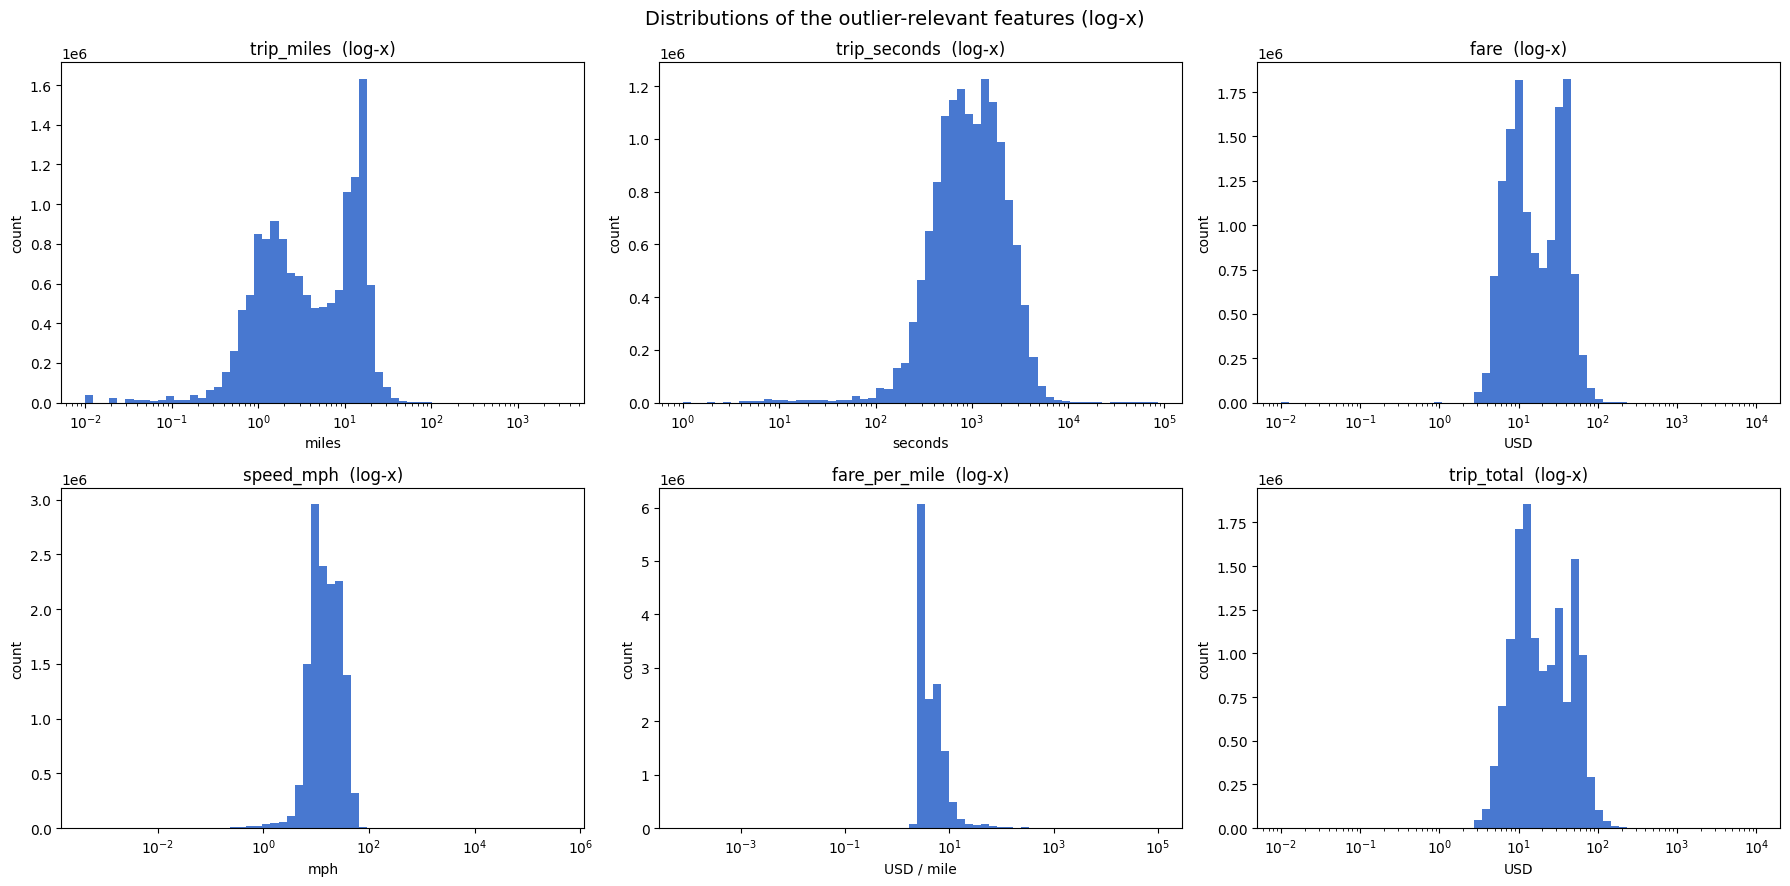

In [25]:
# Log-scaled histograms — with strongly right-skewed taxi distributions a linear axis shows just one bar
plot_feats = [
    ("trip_miles", "miles"), ("trip_seconds", "seconds"), ("fare", "USD"),
    ("speed_mph", "mph"), ("fare_per_mile", "USD / mile"), ("trip_total", "USD"),
]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, (col, unit) in zip(axes.ravel(), plot_feats):
    vals = df_diag[col].replace([np.inf, -np.inf], np.nan).dropna()
    vals = vals[vals > 0]
    bins = np.logspace(np.log10(vals.min()), np.log10(vals.max()), 60)
    ax.hist(vals, bins=bins, color=sns.color_palette("muted")[0], edgecolor="none")
    ax.set_xscale("log")
    ax.set_title(f"{col}  (log-x)")
    ax.set_xlabel(unit); ax.set_ylabel("count")
fig.suptitle("Distributions of the outlier-relevant features (log-x)", fontsize=14)
plt.tight_layout()
plt.show()

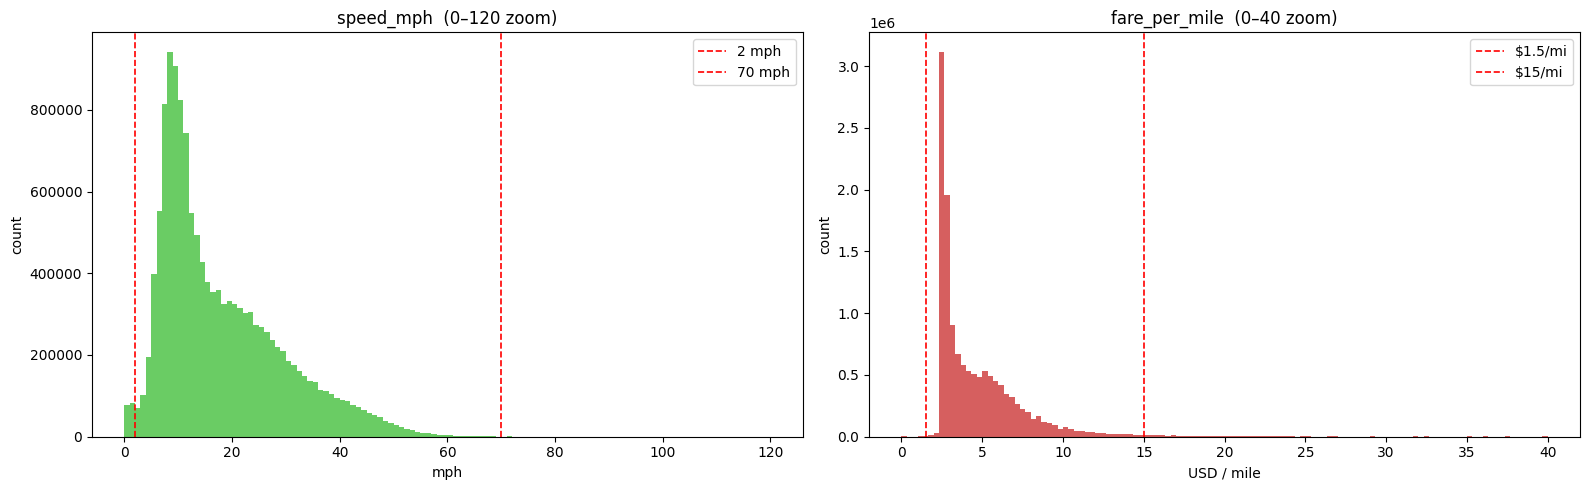

speed_mph      outside [2, 70] mph :  162,141 ( 1.18%)  | undefined (div0): 0
fare_per_mile  outside [1.5, 15] $/mi:  506,083 ( 3.67%)  | undefined (div0): 28,117


In [26]:
# Zoom into the two most important derived features, with candidate thresholds (red)
SPEED_LO, SPEED_HI = 2, 70      # mph      — candidate bounds, validate against the tails!
FPM_LO,   FPM_HI   = 1.5, 15    # USD/mile — candidate bounds, validate against the tails!

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

speed = df_diag["speed_mph"].dropna()
axes[0].hist(speed[speed.between(0, 120)], bins=120,
             color=sns.color_palette("muted")[2], edgecolor="none")
axes[0].axvline(SPEED_LO, color="red", ls="--", lw=1.2, label=f"{SPEED_LO} mph")
axes[0].axvline(SPEED_HI, color="red", ls="--", lw=1.2, label=f"{SPEED_HI} mph")
axes[0].set_title("speed_mph  (0–120 zoom)")
axes[0].set_xlabel("mph"); axes[0].set_ylabel("count"); axes[0].legend()

fpm = df_diag["fare_per_mile"].dropna()
axes[1].hist(fpm[fpm.between(0, 40)], bins=120,
             color=sns.color_palette("muted")[3], edgecolor="none")
axes[1].axvline(FPM_LO, color="red", ls="--", lw=1.2, label=f"${FPM_LO}/mi")
axes[1].axvline(FPM_HI, color="red", ls="--", lw=1.2, label=f"${FPM_HI}/mi")
axes[1].set_title("fare_per_mile  (0–40 zoom)")
axes[1].set_xlabel("USD / mile"); axes[1].set_ylabel("count"); axes[1].legend()

plt.tight_layout()
plt.show()

# Share outside the candidate corridors (NaN = undefined due to division by zero, reported separately)
for col, lo, hi, unit in [("speed_mph", SPEED_LO, SPEED_HI, "mph"),
                          ("fare_per_mile", FPM_LO, FPM_HI, "$/mi")]:
    s = df_diag[col]
    outside = (~s.between(lo, hi)) & s.notna()
    print(f"{col:<14} outside [{lo}, {hi}] {unit:<4}: {outside.sum():>8,} ({outside.mean():6.2%})"
          f"  | undefined (div0): {s.isna().sum():,}")

### Deep Dive: `trip_total` Consistency

The rule-violation table above flags a large share of trips where `trip_total ≠ fare + tips + tolls + extras`. A share that high is unlikely to be random — it points to a *systematic* cause, and the right treatment depends entirely on which one. Blindly recomputing `trip_total` from the component columns could discard a legitimate fee. So before deciding, we characterise the residual along three axes:

1. **Magnitude** — are the deviations cents (rounding noise, exaggerated by the strict `|d| > 0.01` cutoff) or dollars (real gaps)?
2. **Structure** — is the gap a recurring *constant* (a fixed fee/tax) or a smear of random values (corruption)?
3. **Drivers** — does it cluster by `payment_type`, `company`, or a specific `month` (a charge introduced on a date)?

In [27]:
# --- Magnitude: how large are the deviations, really? ---
# Signed residual: positive => trip_total exceeds the component sum (possible missing fee)
resid = df_diag["total_check"]   # = trip_total - (fare + tips + tolls + extras)

print("Signed residual (USD):")
display(resid.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(3))

# Share of trips within increasing tolerance bands — separates rounding noise from real gaps
bands = [0.001, 0.01, 0.05, 0.10, 0.50, 1.00]
print("\nShare of trips within |residual| <= band:")
for b in bands:
    print(f"  |d| <= ${b:>5.3f} : {(resid.abs() <= b).mean():7.2%}")
print(f"  |d|  > ${bands[-1]:>5.2f} : {(resid.abs() > bands[-1]).mean():7.2%}")

Signed residual (USD):


count    1.375405e+07
mean     2.620000e-01
std      3.510000e-01
min     -0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
50%      0.000000e+00
95%      5.000000e-01
99%      5.000000e-01
max      4.000000e+00
Name: total_check, dtype: float64


Share of trips within |residual| <= band:
  |d| <= $0.001 :  51.89%
  |d| <= $0.010 :  51.89%
  |d| <= $0.050 :  51.89%
  |d| <= $0.100 :  51.89%
  |d| <= $0.500 :  98.09%
  |d| <= $1.000 :  98.87%
  |d|  > $ 1.00 :   0.93%


In [28]:
# --- Structure: is the gap a constant (systematic fee) or random noise? ---
nonzero = resid[resid.abs() > 0.01]

print(f"Inconsistent trips (|d| > 0.01): {len(nonzero):,} ({len(nonzero) / len(resid):.1%})")
print(f"  positive (trip_total > sum): {(nonzero > 0).mean():.1%}")
print(f"  negative (trip_total < sum): {(nonzero < 0).mean():.1%}")

print("\nMost frequent residual values (rounded to cent) among inconsistent trips:")
display(nonzero.round(2).value_counts().head(12).to_frame("count"))

Inconsistent trips (|d| > 0.01): 6,602,205 (47.9%)
  positive (trip_total > sum): 100.0%
  negative (trip_total < sum): 0.0%

Most frequent residual values (rounded to cent) among inconsistent trips:


,count
total_check,
0.50,6469593
3.00,71132
2.50,52907
1.00,4695
3.50,3433
1.50,189
1.95,123
2.45,75
2.00,49


In [29]:
# --- Does the inconsistency cluster by payment type, company or over time? ---
tmp = df_diag[["payment_type", "company"]].copy()
tmp["resid"] = resid
tmp["inconsistent"] = resid.abs() > 0.01
tmp["month"] = df_diag["trip_start_timestamp"].dt.tz_localize(None).dt.to_period("M").astype(str)

def breakdown(col, top=10):
    g = tmp.groupby(col).agg(
        n=("resid", "size"),
        share_inconsistent=("inconsistent", "mean"),
        median_resid=("resid", "median"),
        mean_resid=("resid", "mean"),
    )
    return g.sort_values("n", ascending=False).head(top).round(3)

print("By payment_type:")
display(breakdown("payment_type"))

print("By company (top 10 by volume):")
display(breakdown("company"))

print("By month:")
display(
    tmp.groupby("month")
    .agg(n=("resid", "size"),
         share_inconsistent=("inconsistent", "mean"),
         median_resid=("resid", "median"))
    .round(3)
)

By payment_type:


,n,share_inconsistent,median_resid,mean_resid
payment_type,,,,
Credit Card,5073708,0.757,0.5,0.405
Mobile,3441014,0.788,0.5,0.412
Cash,3105149,0.016,0.0,0.041
Prcard,1639147,0.000,0.0,0.001
Unknown,494918,0.000,0.0,-0.000
No Charge,23519,0.000,0.0,0.000
Dispute,4709,0.000,0.0,0.000


By company (top 10 by volume):


,n,share_inconsistent,median_resid,mean_resid
company,,,,
Flash Cab,2879447,0.359,0.0,0.196
Taxicab Insurance Agency Llc,1738891,0.690,0.5,0.377
Sun Taxi,1601510,0.685,0.5,0.376
City Service,1457260,0.649,0.5,0.357
Taxi Affiliation Services,1329037,0.000,0.0,0.000
Chicago Independents,919317,0.665,0.5,0.357
5 Star Taxi,700208,0.572,0.5,0.307
Transit Administrative Center Inc,642394,0.000,0.0,0.000
Blue Ribbon Taxi Association,625187,0.570,0.5,0.314


By month:


,n,share_inconsistent,median_resid
month,,,
2024-01,374266,0.334,0.0
2024-02,387024,0.340,0.0
2024-03,458504,0.346,0.0
2024-04,477171,0.354,0.0
2024-05,537346,0.370,0.0
2024-06,525128,0.377,0.0
2024-07,475725,0.356,0.0
2024-08,495768,0.357,0.0
2024-09,496961,0.369,0.0


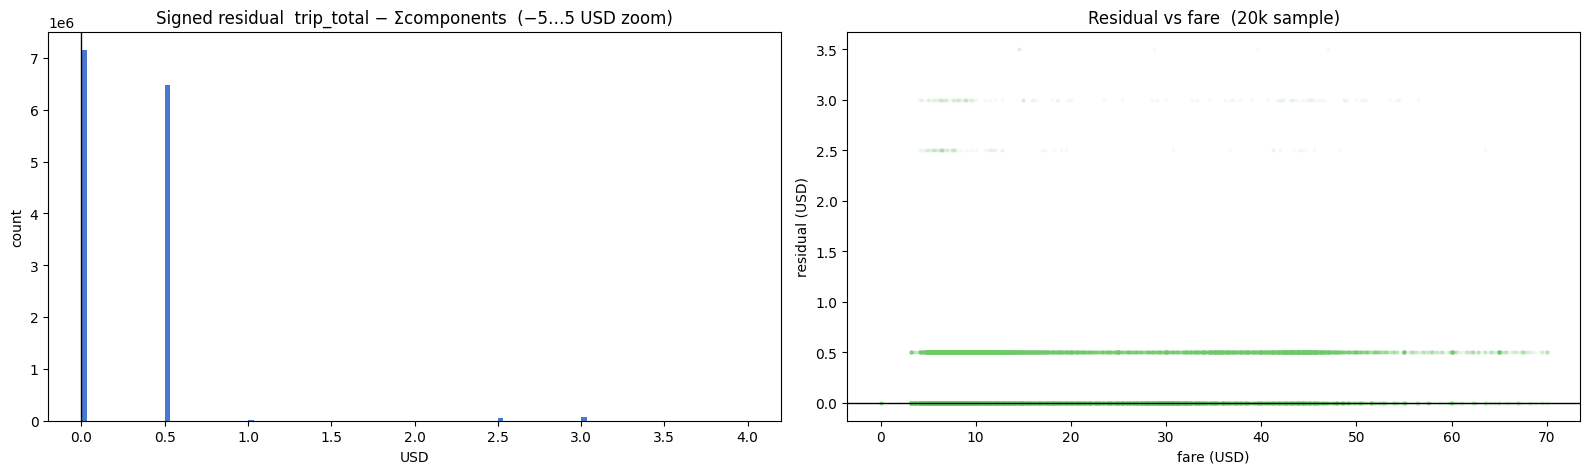

In [30]:
# --- Visualize the residual: shape and whether it scales with fare ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

r_zoom = resid[resid.between(-5, 5)]
axes[0].hist(r_zoom, bins=120, color=sns.color_palette("muted")[0], edgecolor="none")
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Signed residual  trip_total − Σcomponents  (−5…5 USD zoom)")
axes[0].set_xlabel("USD"); axes[0].set_ylabel("count")

# Residual vs fare: a flat band => fixed fee; a diagonal => percentage charge
samp = pd.DataFrame({"fare": df_diag["fare"], "resid": resid}).dropna()
samp = samp[samp["fare"].between(0, samp["fare"].quantile(0.99)) & samp["resid"].between(-5, 5)]
samp = samp.sample(min(20_000, len(samp)), random_state=42)
axes[1].scatter(samp["fare"], samp["resid"], alpha=0.05, s=4, color=sns.color_palette("muted")[2])
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Residual vs fare  (20k sample)")
axes[1].set_xlabel("fare (USD)"); axes[1].set_ylabel("residual (USD)")

plt.tight_layout()
plt.show()

**How to read this:**

- **Residual overwhelmingly within ±\$0.05** → the high "inconsistent" share is essentially float/rounding noise from the strict `|d| > 0.01` cutoff. Keep `trip_total` as-is and simply relax the tolerance; do **not** recompute.
- **A single constant dominates `value_counts` (e.g. +\$1.00)**, or the residual forms a flat positive band in the *residual-vs-fare* scatter → a **fixed fee/tax is missing** from the component columns. Recomputing `fare+tips+tolls+extras` would understate revenue — keep `trip_total`, or expose the gap as a `surcharge` feature.
- **Residual scales with fare** (diagonal in the scatter) → a **percentage charge** (e.g. a platform fee) is missing; again `trip_total` is the more complete figure.
- **Residual clusters on a `month`** → a charge introduced on a specific date; `trip_total` already reflects it while the components lag.
- **Large and structureless** → genuine corruption. Only then decide per use case (for price/revenue, trust `trip_total`; the components are the weaker signal).

Net: choose the treatment **after** seeing which pattern emerges above — do not blindly sum the component columns. Note that [03_spatial_analytics.ipynb](03_spatial_analytics.ipynb) currently rebuilds `trip_total = fare + tips` (dropping `tolls`/`extras`); if `trip_total` turns out reliable, that should switch back to the original column.

### Final Outlier Cutoffs

The diagnostics above expose where the distributions stop being physically plausible. We now fix the bounds. Two distinct treatments apply:

- **Rule 1 — drop (data errors):** records that are physically or operationally impossible. These are *not* demand and must leave the dataset entirely.
- **Rule 2 — cap / winsorize (genuine extremes):** rare but real values (long airport runs, high fares) that would dominate the scale-sensitive SVM / neural network. These are clipped to **p99.9** *only* when building model features — never dropped, so they still count as demand in the spatial/temporal aggregates.

We read each bound off the actual tails rather than using round numbers:

| Feature | Cutoff (drop) | Share | Justification |
|---|---|---|---|
| `fare` | `<= 0` | 0.038 % | A metered trip cannot bill \$0. |
| `trip_miles` | `> 100` | 0.007 % | Chicago metro spans ~50 mi; p99.9 = 42.10. >100 mi is geographically impossible. |
| `trip_seconds` | `> 10,800` (3 h) | 0.084 % | p99.9 = 9,632 s (2.7 h). Beyond 3 h the meter was left running. |
| `speed_mph` (high) | `> 70` | 0.048 % | p99.9 = 62.55; legal sustained max ~55–60 mph. The 423,304 mph max confirms GPS teleports live here. |
| `speed_mph` (low) | `< 2` | 1.128 % | Stuck-meter / under-recorded distance. **Most aggressive bound** — see note. |
| `fare_per_mile` (low) | `< 2.0` | 0.207 % | **Strongest bound:** the \$2.25/mi tariff makes <\$2/mi impossible; the empirical p1 is 2.40, confirming it. |
| `fare_per_mile` (high) | `> 100` | 0.839 % | p99 = 79.69. Genuine meter errors only start in the far tail. |

**Two cutoffs that required a judgment call (worth flagging in the report):**

1. **`speed_mph < 2` removes ~1.1 %, and the boundary is genuinely fuzzy.** A 0.5-mile trip (p5 of distance) over the median 955 s averages ~1.9 mph — i.e. real gridlock sits right at the threshold. We keep `< 2` as the stuck-meter band but report the count so the choice is transparent; a more conservative analyst could use `< 1` or make it conditional on long duration.
2. **We deliberately do *not* apply a tight upper cap on `fare_per_mile`.** The candidate \$15/mi would drop a significant share of trips (p95 = 12.03), but that tail is dominated by *legitimate short trips* where the fixed base fare inflates the ratio (a \$5, 0.3-mile trip = \$16.7/mi is valid). Only the far tail (`> 100`) is a true meter error.

The two most rigorously grounded bounds are `fare_per_mile < 2.0` (matches both the tariff and the empirical p1) and `speed_mph > 70` (above any legal sustained speed and p99.9).

These thresholds are wired into `preprocess_taxi_data()` in `scripts/helpers/preprocessing.py` as module-level constants (`SPEED_MIN_MPH`, `SPEED_MAX_MPH`, `TRIP_SECONDS_MAX`, `TRIP_MILES_MAX`, `FARE_PER_MILE_MIN`, `FARE_PER_MILE_MAX`). Below we apply them here for transparency — logging rows removed per rule — and run the sensitivity check the assignment requires (demand aggregate with vs. without the filters).

In [31]:
# ── Apply the final outlier cutoffs (Rule 1) and log rows removed per rule ──
# These mirror the constants in scripts/helpers/preprocessing.py exactly.
from scripts.helpers.preprocessing import (
    SPEED_MIN_MPH, SPEED_MAX_MPH, TRIP_SECONDS_MAX,
    TRIP_MILES_MAX, FARE_PER_MILE_MIN, FARE_PER_MILE_MAX,
)

speed = (df["trip_miles"] / (df["trip_seconds"] / 3600)).replace([np.inf, -np.inf], np.nan)
fpm   = (df["fare"]       /  df["trip_miles"]).replace([np.inf, -np.inf], np.nan)

rules = {
    "fare <= 0":                          df["fare"] <= 0,
    f"trip_miles > {TRIP_MILES_MAX:g}":   df["trip_miles"] > TRIP_MILES_MAX,
    "trip_seconds > 3 h":                 df["trip_seconds"] > TRIP_SECONDS_MAX,
    f"speed > {SPEED_MAX_MPH:g} mph":     speed > SPEED_MAX_MPH,
    f"speed < {SPEED_MIN_MPH:g} mph":     speed < SPEED_MIN_MPH,
    f"fare_per_mile < {FARE_PER_MILE_MIN:g}": fpm < FARE_PER_MILE_MIN,
    f"fare_per_mile > {FARE_PER_MILE_MAX:g}": fpm > FARE_PER_MILE_MAX,
}

n0 = len(df)
drop_any = pd.Series(False, index=df.index)
print(f"{'rule':<24}{'flagged':>12}{'share':>10}")
print("-" * 46)
for name, mask in rules.items():
    mask = mask.fillna(False)          # inf/NaN derived values -> treated as drop
    print(f"{name:<24}{mask.sum():>12,}{mask.mean():>10.3%}")
    drop_any |= mask

df_clean = df[~drop_any].copy()
print("-" * 46)
print(f"{'union (rows dropped)':<24}{drop_any.sum():>12,}{drop_any.mean():>10.3%}")
print(f"\n{n0:,} -> {len(df_clean):,} trips")

rule                         flagged     share
----------------------------------------------
fare <= 0                      5,243    0.038%
trip_miles > 100                 960    0.007%
trip_seconds > 3 h            11,629    0.084%
speed > 70 mph                 6,663    0.048%
speed < 2 mph                155,478    1.128%
fare_per_mile < 2             28,537    0.207%
fare_per_mile > 100          115,685    0.839%
----------------------------------------------
union (rows dropped)         269,239    1.954%

13,782,164 -> 13,512,925 trips


In [32]:
# ── Sensitivity check: do the outlier filters distort the demand signal? ──
# If removing ~outliers materially reshaped the spatial demand we model later,
# the filters would be too aggressive. We compare per-community-area pickup
# demand before vs. after, expecting a near-identical geographic pattern.
before = df.groupby("pickup_community_area").size()
after  = df_clean.groupby("pickup_community_area").size()
comp = pd.concat([before, after], axis=1, keys=["before", "after"]).fillna(0)
comp["pct_change"] = (comp["after"] / comp["before"] - 1) * 100

print(f"Total pickups : {before.sum():,} -> {after.sum():,} "
      f"({after.sum() / before.sum() - 1:+.2%})")
print(f"Per-area demand correlation (before vs after): "
      f"{comp['before'].corr(comp['after']):.4f}")
print("\nMost-affected community areas (largest % change):")
display(comp.reindex(comp["pct_change"].abs().sort_values(ascending=False).index).head())

Total pickups : 13,782,164 -> 13,512,925 (-1.95%)
Per-area demand correlation (before vs after): 1.0000

Most-affected community areas (largest % change):


,before,after,pct_change
pickup_community_area,,,
64.0,3461,3092,-10.661658
59.0,17563,16271,-7.356374
65.0,4944,4636,-6.229773
11.0,16023,15102,-5.747987
10.0,30151,28461,-5.605121


## Loading & Preprocessing in Subsequent Notebooks

All steps documented above are encapsulated in two helper scripts so that later notebooks can load a clean dataset in a single line:

- **`scripts/helpers/datasets.py`** — entry point for loading any dataset.
- **`scripts/helpers/preprocessing.py`** — contains `preprocess_taxi_data()`, which applies the selected cleaning tier and derives temporal features.

`load_taxi_data` accepts a `mode` parameter that selects between two cleaning tiers (see the next section for a full explanation):

```python
from scripts.helpers.datasets import load_taxi_data, load_merged_data

# Full trip-level cleaning — use for fare, distance, speed, duration analyses (default)
df = load_taxi_data(preprocessed=True)                    # or mode='trip'

# Minimal cleaning for demand forecasting targets — keeps every valid pickup event
df_demand = load_taxi_data(preprocessed=True, mode='demand')

# Raw data with temporal features only — no cleaning applied
df_raw = load_taxi_data(preprocessed=False)

# Preprocessed taxi + weather joined by zone and hour (always uses mode='trip')
df_merged = load_merged_data()
```

## Summary: Cleaning Ledger

The table below consolidates every cleaning decision into a single audit trail — raw data through to the model-ready dataset — recording how many rows each step removes. It is **recomputed from the raw CSV in the exact order `preprocess_taxi_data()` applies**, so the figures tie out to the pipeline rather than being copied from the narrative above.

In [2]:
# ── Consolidated cleaning ledger (mirrors preprocess_taxi_data step-for-step) ──
import geopandas as gpd
from scripts.helpers.datasets import load_taxi_data
from scripts.helpers import preprocessing as pp

audit = load_taxi_data(preprocessed=False)

ledger = []
def _log(step, kind, frame):
    ledger.append({"step": step, "type": kind, "rows_remaining": len(frame)})

_log("Raw data (Chicago Data Portal)", "load", audit)

# 1 — Drop DST-ambiguous missing timestamps
audit = audit.dropna(subset=["trip_start_timestamp", "trip_end_timestamp"])
_log("Drop missing timestamps (DST artifacts)", "drop", audit)

# 2 — Impute missing community areas via spatial join (no rows removed)
ca = (gpd.read_file(pp.CA_GEOJSON_PATH)[["area_numbe", "geometry"]]
        .rename(columns={"area_numbe": "area_number"}))
ca["area_number"] = pd.to_numeric(ca["area_number"], errors="coerce")
audit = pp._fill_community_area(audit, "pickup_centroid_latitude",  "pickup_centroid_longitude",  "pickup_community_area",  ca)
audit = pp._fill_community_area(audit, "dropoff_centroid_latitude", "dropoff_centroid_longitude", "dropoff_community_area", ca)
_log("Impute missing community areas", "impute", audit)

# 3 — Drop missing taxi_id
audit = audit.dropna(subset=["taxi_id"])
_log("Drop missing taxi_id", "drop", audit)

# 4 — Drop ghost trips (zero duration, same location, start == end)
ghost = (
    (audit["trip_seconds"] == 0)
    & (audit["trip_end_timestamp"] == audit["trip_start_timestamp"])
    & (audit["pickup_centroid_latitude"]  == audit["dropoff_centroid_latitude"])
    & (audit["pickup_centroid_longitude"] == audit["dropoff_centroid_longitude"])
)
audit = audit[~ghost]
_log("Drop ghost trips (0 s, same location)", "drop", audit)

# 5 — Drop zero-mile trips with positive duration (GPS failures)
audit = audit[~((audit["trip_miles"] == 0) & (audit["trip_seconds"] > 0))]
_log("Drop zero-mile / positive-duration (GPS errors)", "drop", audit)

# 6 — Drop implausible outliers (Rule 1)
speed = (audit["trip_miles"] / (audit["trip_seconds"] / 3600)).replace([np.inf, -np.inf], np.nan)
fpm   = (audit["fare"]       /  audit["trip_miles"]).replace([np.inf, -np.inf], np.nan)
keep = (
    (audit["fare"] > 0)
    & (audit["trip_miles"] <= pp.TRIP_MILES_MAX)
    & (audit["trip_seconds"] <= pp.TRIP_SECONDS_MAX)
    & speed.between(pp.SPEED_MIN_MPH, pp.SPEED_MAX_MPH)
    & fpm.between(pp.FARE_PER_MILE_MIN, pp.FARE_PER_MILE_MAX)
)
audit = audit[keep]
_log("Drop implausible outliers (Rule 1)", "drop", audit)

# ── Assemble the ledger table ──
ledger_df = pd.DataFrame(ledger)
n_raw = ledger_df["rows_remaining"].iloc[0]
ledger_df["rows_removed"]    = (-ledger_df["rows_remaining"].diff()).fillna(0).astype(int)
ledger_df["pct_raw_removed"] = (ledger_df["rows_removed"] / n_raw * 100).round(3)
ledger_df["pct_retained"]    = (ledger_df["rows_remaining"] / n_raw * 100).round(2)
ledger_df = ledger_df[["step", "type", "rows_removed", "rows_remaining", "pct_raw_removed", "pct_retained"]]

n_final = ledger_df["rows_remaining"].iloc[-1]
print(f"Raw -> clean: {n_raw:,} -> {n_final:,} trips "
      f"({n_final / n_raw:.2%} retained, {1 - n_final / n_raw:.2%} removed)")
display(ledger_df.style.hide(axis="index"))

Raw -> clean: 14,985,679 -> 13,485,728 trips (89.99% retained, 10.01% removed)


step,type,rows_removed,rows_remaining,pct_raw_removed,pct_retained
Raw data (Chicago Data Portal),load,0,14985679,0.000000,100.000000
Drop missing timestamps (DST artifacts),drop,1128,14984551,0.008000,99.990000
Impute missing community areas,impute,0,14984551,0.000000,99.990000
Drop missing taxi_id,drop,8,14984543,0.000000,99.990000
"Drop ghost trips (0 s, same location)",drop,153078,14831465,1.021000,98.970000
Drop zero-mile / positive-duration (GPS errors),drop,1014515,13816950,6.770000,92.200000
Drop implausible outliers (Rule 1),drop,331222,13485728,2.210000,89.990000


## Two-Tier Cleaning: Demand vs. Trip Analysis

### The problem with a single cleaning pipeline

The full `'trip'` pipeline above removes ~10.65 % of raw records. Most of those removals are correct for trip-level analysis — a trip with `speed_mph = 141,000` or `fare_per_mile = 3,000` would corrupt any fare or speed model. But for **demand forecasting**, the question we're asking is different:

> *How many passengers hailed a taxi at this location during this time window?*

A row with a missing `taxi_id`, a zero-distance GPS failure, or an implausible fare-per-mile ratio still represents a real pickup event. Discarding it understates demand and creates many artificial zero-demand buckets in the time × location grid — which makes the forecasting model significantly harder to fit.

### Two cleaning tiers

`preprocess_taxi_data()` therefore supports a `mode` parameter with two options:

| Filter step | `mode='demand'` | `mode='trip'` (default) |
|---|:---:|:---:|
| Drop NaT timestamps (DST artifacts) | ✓ | ✓ |
| Impute missing community areas via spatial join | ✓ | ✓ |
| Drop missing `taxi_id` | — | ✓ |
| Drop ghost trips (0 s, same location) | — | ✓ |
| Drop zero-mile / positive-duration (GPS errors) | — | ✓ |
| Drop Rule-1 implausible outliers (fare, speed, distance) | — | ✓ |

**When to use each mode:**

- **`mode='demand'`** — building the target variable for demand forecasting (pickup counts per time bucket and spatial unit). Use this whenever you are *counting* pickups, not *analysing* trip characteristics.
- **`mode='trip'`** — any analysis that depends on trip metadata: fare, distance, speed, duration, profitability, fleet utilisation. This is the default so existing notebooks are unaffected.

In [ ]:
# ── Demand-mode cleaning ledger ──
# Load both tiers and compare row counts to confirm the difference is as expected.
df_raw_count = load_taxi_data(preprocessed=False)
df_trip    = load_taxi_data(preprocessed=True, mode='trip')    # full pipeline (default)
df_demand  = load_taxi_data(preprocessed=True, mode='demand')  # minimal pipeline

n_raw    = len(df_raw_count)
n_trip   = len(df_trip)
n_demand = len(df_demand)

print(f"Raw data           : {n_raw:>10,} rows  (100.00%)")
print(f"mode='demand'      : {n_demand:>10,} rows  ({n_demand / n_raw:7.2%} retained)")
print(f"mode='trip'        : {n_trip:>10,} rows  ({n_trip   / n_raw:7.2%} retained)")
print(f"\nDemand mode keeps {n_demand - n_trip:,} extra rows (+{(n_demand - n_trip) / n_trip:.2%})"
      f" over trip mode — those are real pickup events excluded by trip-quality filters.")